ライダーデータ600mmからのデータ

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

data = pd.read_csv('sensor_data/sensor_data_600.txt', delimiter=" ", header=None, names=("date", "time", "ir", "lidar"))
data

,date,time,ir,lidar
0,20180202,110001,28,627
1,20180202,110004,17,626
2,20180202,110007,14,627
3,20180202,110010,31,622
4,20180202,110013,24,630
...,...,...,...,...
82296,20180205,84216,39,634
82297,20180205,84220,13,637
82298,20180205,84222,37,633
82299,20180205,84225,36,633


24時間で取得した距離データの頻度

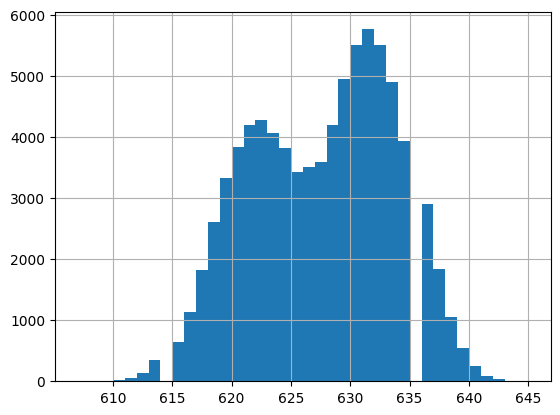

In [93]:
data["lidar"].hist(bins=(max(data['lidar']) - min(data['lidar'])))
plt.show()

センサの時系列解析

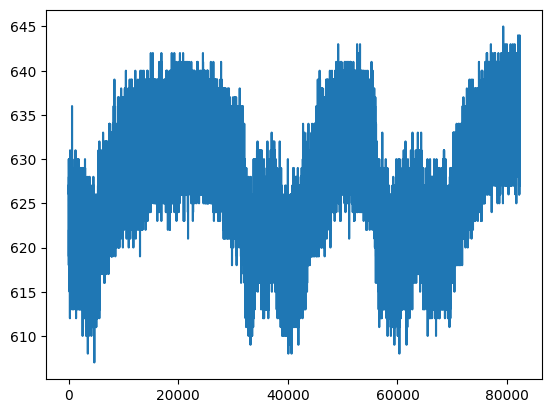

In [94]:
data.lidar.plot()
plt.show()

センサデータを時間ごとにグループ化して可視化

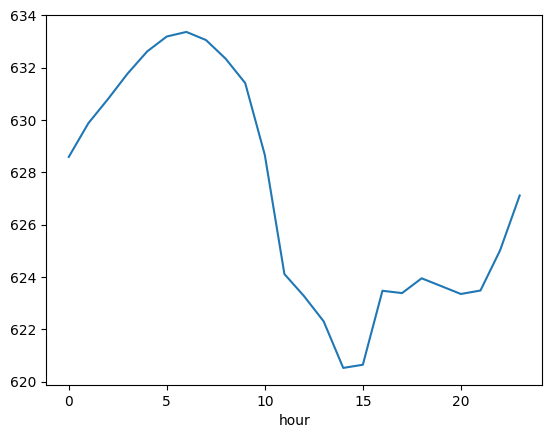

In [95]:
data['hour'] = [e // 10000 for e in data.time] # 1時間ごとに集約
d = data.groupby('hour')
d.lidar.mean().plot()
plt.show()

1時間ごとに集約した距離集合から例えば指定した時間帯のデータを取得する

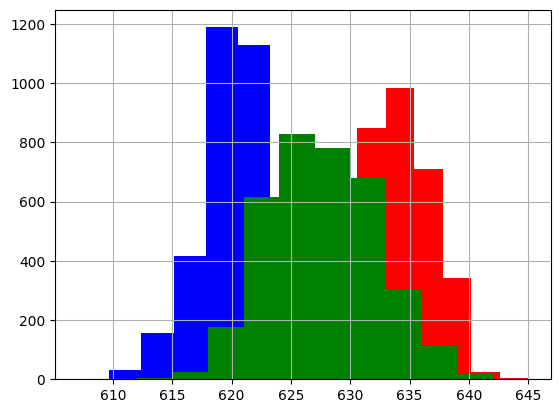

In [96]:
d.lidar.get_group(6).hist(color='red')
d.lidar.get_group(14).hist(color='blue')
d.lidar.get_group(23).hist(color='g')
plt.show()

同時確率

In [97]:
data['time'] # 時間

0        110001
1        110004
2        110007
3        110010
4        110013
          ...  
82296     84216
82297     84220
82298     84222
82299     84225
82300     84228
Name: time, Length: 82301, dtype: int64

In [98]:
data["lidar"] # 600mm距離のライダーセンサの値一覧

0        627
1        626
2        627
3        622
4        630
        ... 
82296    634
82297    637
82298    633
82299    633
82300    634
Name: lidar, Length: 82301, dtype: int64

In [99]:
each_hour = { i: d.lidar.get_group(i).value_counts().sort_index() for i in range(24) } # 時間ごとにデータフレームを作成
each_hour # 0時から23時までの1時間ごとの距離の頻度

{0: lidar
 618      3
 619     18
 620     32
 621     46
 622     85
 623    132
 624    179
 625    252
 626    308
 627    316
 628    365
 629    361
 630    338
 631    342
 632    250
 633    213
 634    128
 636     71
 637     57
 638     30
 639     11
 640      1
 641      1
 642      1
 Name: count, dtype: int64,
 1: lidar
 619      4
 620      6
 621     13
 622     18
 623     44
 624     80
 625    150
 626    221
 627    267
 628    377
 629    422
 630    467
 631    396
 632    371
 633    254
 634    205
 636    121
 637     71
 638     25
 639     13
 640      5
 641      1
 642      1
 Name: count, dtype: int64,
 2: lidar
 619      1
 620      3
 621      3
 622      7
 623     19
 624     45
 625     75
 626    124
 627    171
 628    312
 629    426
 630    471
 631    470
 632    424
 633    369
 634    279
 636    172
 637     91
 638     42
 639     14
 640      8
 641      2
 642      1
 Name: count, dtype: int64,
 3: lidar
 620      1
 622      2
 623      3


In [100]:
freqs = pd.concat(each_hour, axis=1)
freqs # 欠損値(NA)がある

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
lidar,,,,,,,,,,,,,,,,,,,,,
618,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,356.0,312.0,91.0,144.0,146.0,187.0,240.0,258.0,157.0,33.0
619,18.0,4.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,410.0,354.0,149.0,222.0,190.0,275.0,301.0,286.0,209.0,60.0
620,32.0,6.0,3.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,423.0,442.0,238.0,248.0,223.0,339.0,321.0,298.0,221.0,84.0
621,46.0,13.0,3.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,...,405.0,465.0,322.0,305.0,263.0,365.0,289.0,328.0,284.0,156.0
622,85.0,18.0,7.0,2.0,NaN,NaN,NaN,NaN,NaN,5.0,...,395.0,414.0,445.0,363.0,344.0,309.0,252.0,250.0,286.0,192.0
623,132.0,44.0,19.0,3.0,4.0,1.0,1.0,2.0,1.0,3.0,...,328.0,320.0,509.0,368.0,318.0,223.0,194.0,193.0,269.0,269.0
624,179.0,80.0,45.0,16.0,5.0,4.0,2.0,4.0,8.0,11.0,...,229.0,261.0,457.0,357.0,354.0,209.0,151.0,160.0,221.0,286.0
625,252.0,150.0,75.0,38.0,12.0,4.0,7.0,9.0,24.0,34.0,...,150.0,185.0,424.0,324.0,302.0,152.0,91.0,111.0,195.0,252.0
626,308.0,221.0,124.0,90.0,38.0,20.0,18.0,31.0,46.0,55.0,...,111.0,118.0,309.0,280.0,290.0,160.0,103.0,87.0,170.0,292.0


In [101]:
freqs = freqs.fillna(0) # 欠損値を0埋め
freqs

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
lidar,,,,,,,,,,,,,,,,,,,,,
618,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,356.0,312.0,91.0,144.0,146.0,187.0,240.0,258.0,157.0,33.0
619,18.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,410.0,354.0,149.0,222.0,190.0,275.0,301.0,286.0,209.0,60.0
620,32.0,6.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,423.0,442.0,238.0,248.0,223.0,339.0,321.0,298.0,221.0,84.0
621,46.0,13.0,3.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,405.0,465.0,322.0,305.0,263.0,365.0,289.0,328.0,284.0,156.0
622,85.0,18.0,7.0,2.0,0.0,0.0,0.0,0.0,0.0,5.0,...,395.0,414.0,445.0,363.0,344.0,309.0,252.0,250.0,286.0,192.0
623,132.0,44.0,19.0,3.0,4.0,1.0,1.0,2.0,1.0,3.0,...,328.0,320.0,509.0,368.0,318.0,223.0,194.0,193.0,269.0,269.0
624,179.0,80.0,45.0,16.0,5.0,4.0,2.0,4.0,8.0,11.0,...,229.0,261.0,457.0,357.0,354.0,209.0,151.0,160.0,221.0,286.0
625,252.0,150.0,75.0,38.0,12.0,4.0,7.0,9.0,24.0,34.0,...,150.0,185.0,424.0,324.0,302.0,152.0,91.0,111.0,195.0,252.0
626,308.0,221.0,124.0,90.0,38.0,20.0,18.0,31.0,46.0,55.0,...,111.0,118.0,309.0,280.0,290.0,160.0,103.0,87.0,170.0,292.0


すべての時間帯の各距離の頻度をすべてのデータ数で割ると同時確率が得られる
+ p(z,t)

In [102]:
probs = freqs / len(data)
probs

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
lidar,,,,,,,,,,,,,,,,,,,,,
618,0.000036,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.004326,0.003791,0.001106,0.001750,0.001774,0.002272,0.002916,0.003135,0.001908,0.000401
619,0.000219,0.000049,0.000012,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.004982,0.004301,0.001810,0.002697,0.002309,0.003341,0.003657,0.003475,0.002539,0.000729
620,0.000389,0.000073,0.000036,0.000012,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.005140,0.005371,0.002892,0.003013,0.002710,0.004119,0.003900,0.003621,0.002685,0.001021
621,0.000559,0.000158,0.000036,0.000000,0.000000,0.000012,0.000012,0.000000,0.000000,0.000000,...,0.004921,0.005650,0.003912,0.003706,0.003196,0.004435,0.003512,0.003985,0.003451,0.001895
622,0.001033,0.000219,0.000085,0.000024,0.000000,0.000000,0.000000,0.000000,0.000000,0.000061,...,0.004799,0.005030,0.005407,0.004411,0.004180,0.003755,0.003062,0.003038,0.003475,0.002333
623,0.001604,0.000535,0.000231,0.000036,0.000049,0.000012,0.000012,0.000024,0.000012,0.000036,...,0.003985,0.003888,0.006185,0.004471,0.003864,0.002710,0.002357,0.002345,0.003268,0.003268
624,0.002175,0.000972,0.000547,0.000194,0.000061,0.000049,0.000024,0.000049,0.000097,0.000134,...,0.002782,0.003171,0.005553,0.004338,0.004301,0.002539,0.001835,0.001944,0.002685,0.003475
625,0.003062,0.001823,0.000911,0.000462,0.000146,0.000049,0.000085,0.000109,0.000292,0.000413,...,0.001823,0.002248,0.005152,0.003937,0.003669,0.001847,0.001106,0.001349,0.002369,0.003062
626,0.003742,0.002685,0.001507,0.001094,0.000462,0.000243,0.000219,0.000377,0.000559,0.000668,...,0.001349,0.001434,0.003755,0.003402,0.003524,0.001944,0.001252,0.001057,0.002066,0.003548


In [103]:
probs = probs.sort_index() # 距離値でソート
probs

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
lidar,,,,,,,,,,,,,,,,,,,,,
607,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000012,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
608,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000012,0.000000,0.000000,0.000000,0.000000,0.000000,0.000012,0.000012,0.000000,0.000000
609,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000024,0.000000,0.000000,0.000000,0.000000,0.000000,0.000012,0.000012,0.000000
610,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000036,0.000049,0.000000,0.000000,0.000012,0.000012,0.000134,0.000000,0.000000,0.000000
611,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000146,0.000122,0.000000,0.000000,0.000000,0.000024,0.000073,0.000146,0.000049,0.000000
612,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000219,0.000316,0.000000,0.000036,0.000036,0.000061,0.000255,0.000194,0.000024,0.000012
613,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000620,0.000644,0.000024,0.000182,0.000061,0.000219,0.000680,0.000437,0.000109,0.000024
615,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.001300,0.001045,0.000024,0.000207,0.000267,0.000377,0.000984,0.001021,0.000474,0.000049
616,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.001956,0.001810,0.000219,0.000595,0.000595,0.001021,0.001725,0.001397,0.000595,0.000085


In [104]:
! pip install seaborn

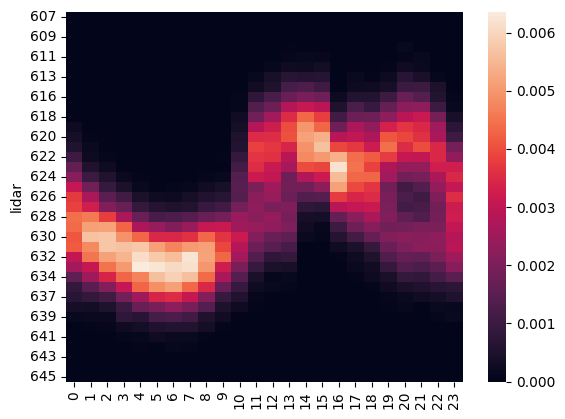

In [105]:
import seaborn as sns

sns.heatmap(probs)
plt.show()

/home/inoue/miniconda3/envs/Py312Env/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'datea'
  cset = contour_func(


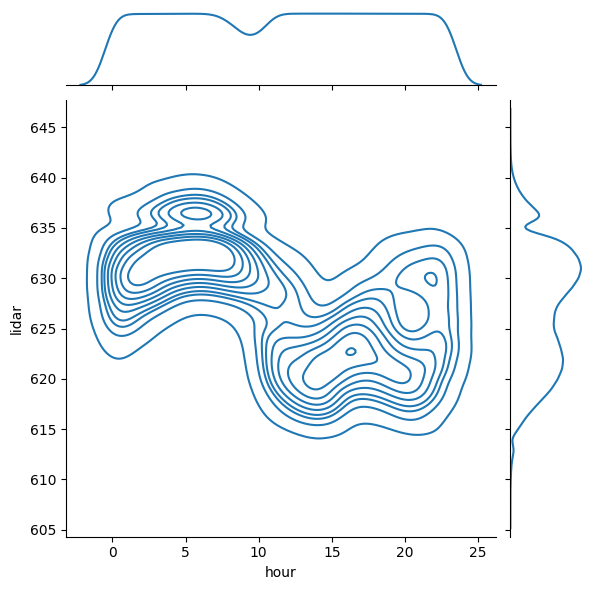

In [106]:
sns.jointplot(datea=data, x=data['hour'], y=data['lidar'], kind='kde') # 2次元のカーネル密度推定
plt.show()

p(z,t)を周辺化してp(t)を取得
+ p(t)

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,0.043013,0.042916,0.042879,0.042916,0.042964,0.043037,0.043061,0.043001,0.038712,0.028651,...,0.043183,0.043122,0.043061,0.043122,0.043049,0.043086,0.043159,0.042976,0.043049,0.043037


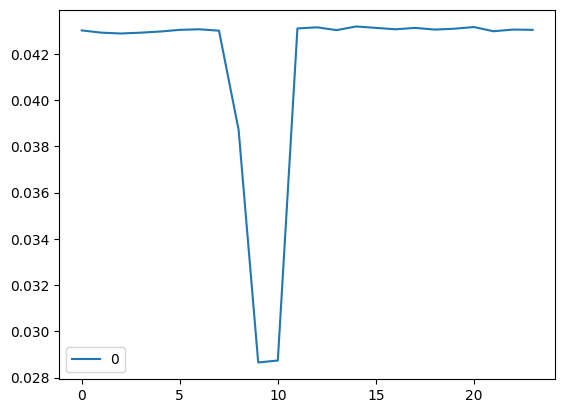

In [107]:
p_t = pd.DataFrame(probs.sum()) # 各列を合計
p_t.plot()
p_t.transpose() # 横ベクトルで表示

p(t)を合計すると確率1.0になる

In [108]:
p_t.sum()

0    1.0
dtype: float64

p(z,t)を周辺化してp(z)を取得する
+ p(z)

lidar,607,608,609,610,611,612,613,615,616,617,...,636,637,638,639,640,641,642,643,644,645
0,0.000012,0.000049,0.000061,0.000328,0.00068,0.00158,0.004241,0.007752,0.013852,0.022053,...,0.03537,0.02226,0.012819,0.006671,0.002989,0.000996,0.000401,0.000109,0.000024,0.000012


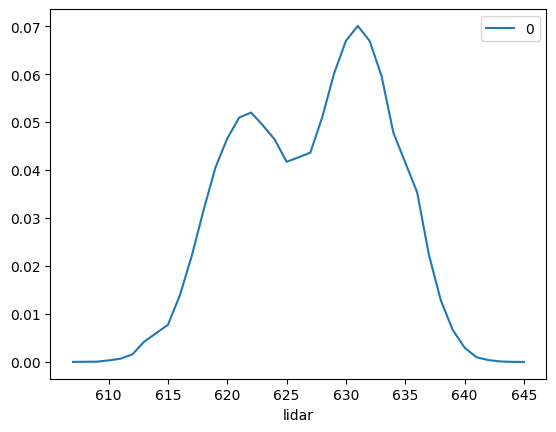

In [109]:
p_z = pd.DataFrame(probs.transpose().sum()) # 行列を転置して各列(各距離ごとの確率の和を取る)
# print(p_z)
p_z.plot()
p_z.transpose()

In [110]:
p_z.sum()

0    1.0
dtype: float64

p(z,t)とp(t)からp(z|t)を取得する
+ p(z|t)

In [111]:
cond_z_t = probs / p_t[0] # 列(時間)ごとにp(t)で割るとp(z|t)となる
cond_z_t # p(z|t) t=0-23, z=607-645

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
lidar,,,,,,,,,,,,,,,,,,,,,
607,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000281,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
608,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000281,0.000000,0.000000,0.000000,0.000000,0.000000,0.000282,0.000283,0.000000,0.000000
609,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000564,0.000000,0.000000,0.000000,0.000000,0.000000,0.000283,0.000282,0.000000
610,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000844,0.001127,0.000000,0.000000,0.000282,0.000282,0.003097,0.000000,0.000000,0.000000
611,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.003376,0.002818,0.000000,0.000000,0.000000,0.000564,0.001689,0.003393,0.001129,0.000000
612,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.005065,0.007326,0.000000,0.000845,0.000847,0.001410,0.005912,0.004524,0.000564,0.000282
613,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.014350,0.014934,0.000564,0.004227,0.001411,0.005076,0.015766,0.010178,0.002540,0.000565
615,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.030107,0.024232,0.000564,0.004790,0.006209,0.008742,0.022804,0.023749,0.011008,0.001129
616,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.045301,0.041984,0.005079,0.013807,0.013830,0.023689,0.039977,0.032513,0.013830,0.001976


条件付き確率p(z|t)をt指定でプロット

<Axes: xlabel='lidar'>

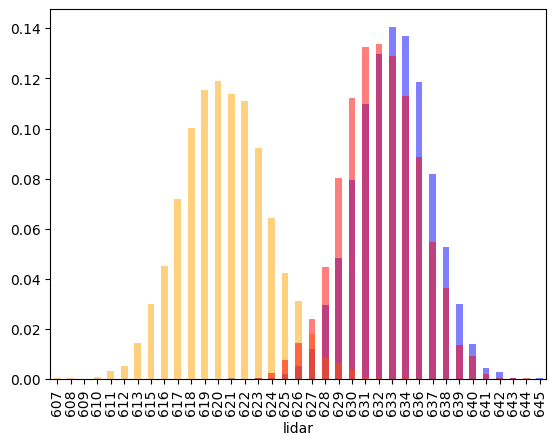

In [112]:
cond_z_t[6].plot.bar(color="blue", alpha=0.5)
cond_z_t[14].plot.bar(color="orange", alpha=0.5)
cond_z_t[8].plot.bar(color="red", alpha=0.5)

ベイズの定理

P(z=630 | t=13) について2種類の計算式の結果を比較する
1. ベイズの定理 p(t|z) = p(z,t) / p(z)
2. 条件付き確率p(z|t)から直接指定

In [113]:
# p(t|z)
cond_t_z = probs.transpose() / probs.transpose().sum() # 行: 時間, 列: 距離 p(t|z) = p(z,t) / p(z)

# センサ値が630になる確率(何時かの情報はない)
print("P(z=630) = ", p_z[0][630])

# 時間が13時である確率
print("P(t=13) = ", p_t[0][13])

# p(t|z)
print("P(t=13|z=630) = ", cond_t_z[630][13])

### 計算式 1. ベイズの定理 ###
print("Bayes P(z=630|t=13) = ", cond_t_z[630][13] * p_z[0][630] / p_t[0][13])

### 計算式 2. 条件付き確率P(z|t)から直接指定 ###
print("answer P(z=630|t=13) = ", cond_z_t[13][630])



P(z=630) =  0.06694936878045224
P(t=13) =  0.043024993620976656
P(t=13|z=630) =  0.023230490018148822
Bayes P(z=630|t=13) =  0.036147980796385204
answer P(z=630|t=13) =  0.036147980796385204


センサ値から計測をした時間帯を推定する関数

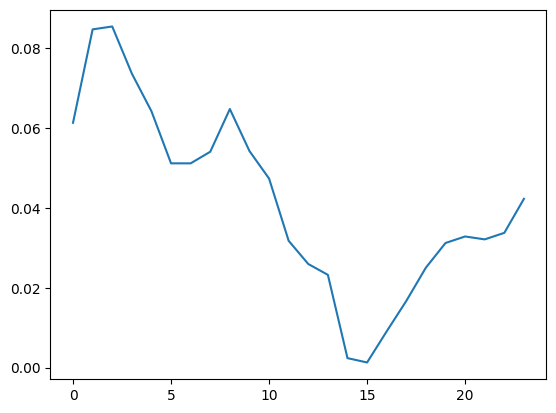

In [114]:
def bayes_estimation(sensor_value, # z
                     current_estimation, # p(t) or p(t|z_now) 時間0-23が確率変数の定義域である確率分布
                     ):
    new_estimation = []
    for i in range(24):
        new_estimation.append(cond_z_t[i][sensor_value] * current_estimation[i]) # p(t|z) ∝ p(z|t) * p(t)
    return new_estimation / sum(new_estimation) # p(t|z) = p(z|t) * p(t) / p(z): 正規化してp(t|z)を返す

# z=630と時間に関する確率分布p(t) or p(t|z_now)が与えられたときの次のステップの時間の条件付き確率p(t|z)
estimation_t = bayes_estimation(630, p_t[0])
plt.plot(estimation_t)

P(t|z1,z2,z3) = η * P(z1,z2,z3|t)P(t) -> η * P(z1|t) * P(z2|t) * P(z3|t) * P(t)
+ P(z|t)を時系列的に順番に掛け算していくだけで, z1,z2,z3が得られた時間帯の確率分布P(t|z_*...)が得られる

更新
1. P(t|z1) ∝ η * P(z=z1|t) * P(t)
2. P(t|z1,z2) ∝ η * P(z=z2|t) * P(t|z=z1)
3. P(t|z1,z2,z3) ∝ η * P(z=z3|t) * P(t|z=z2)

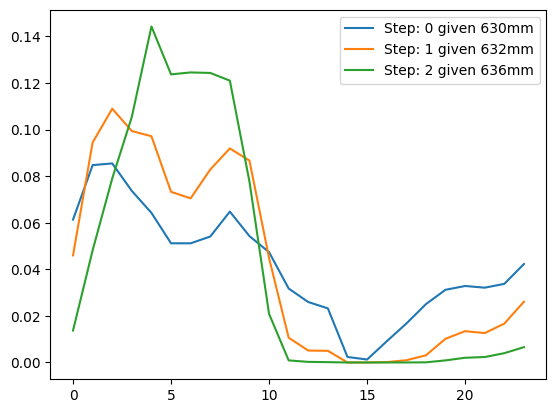

In [115]:
values_5h = [630,632,636] # 5時台で取得できたLidarのセンサ値
estimation_t = p_t[0]
for idx, sv in enumerate(values_5h):
    estimation_t = bayes_estimation(sv, estimation_t) # 条件付き確率P(z|t)を事前に知っているとP(t|z)が計算できる
    plt.plot(estimation_t,label=f"Step: {idx} given {sv}mm")

plt.legend()
plt.show() # およそ，3-8時台の確率が高く大雑把に5時台を推定できている

センサ値は天候の影響を受けるので直接センサ値から時間帯を推定する方法は爪が甘い．下記は11時台の3つのデータだが13,14,15時の確率が高い

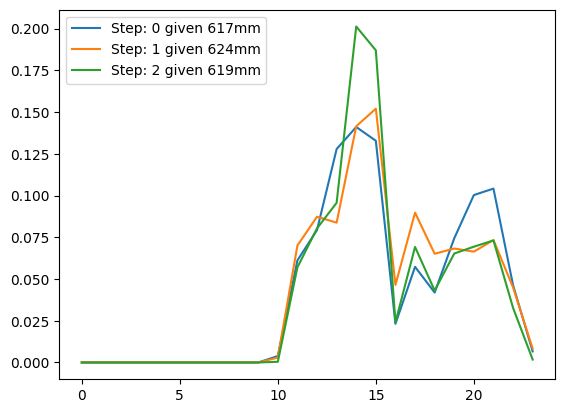

In [116]:
values_11h = [617,624,619] # 11時台
estimation_t = p_t[0]
for idx, sv in enumerate(values_11h):
    estimation_t = bayes_estimation(sv, estimation_t) # 条件付き確率P(z|t)を事前に知っているとP(t|z)が計算できる
    plt.plot(estimation_t,label=f"Step: {idx} given {sv}mm")

plt.legend()
plt.show()